# Manifold-Adherence Techniques — Aggregated Multi-Seed Study

**HalfCheetah-v5 · IL warm-start → PPO fine-tuning**

This notebook is the manifold-adherence counterpart to `il_rl_plasticity_aggregate.ipynb`.
It reuses the **identical** IL-data-collection / PPO / eval / bootstrap scaffolding, and
swaps out the *intervention* under test: instead of plasticity techniques (Shrink-and-Perturb,
Injection), it compares **manifold-adherence** techniques ported from `adherence/`
(Lyapunov safety regularization, multi-step lookahead) applied during the IL (behavior
cloning) phase, each warm-starting the same PPO fine-tuning loop.

**Methods compared**

| id | name | intervention | where |
|----|------|--------------|-------|
| `base`      | Base (control)         | none — plain IL→PPO warm start                     | — |
| `lyapunov`  | Lyapunov Adherence     | Lyapunov safety loss during BC (penalizes V(s,a) increasing along rollout) | IL (BC) loop |
| `twostep`   | Two-Step Lookahead     | multi-step lookahead loss during BC (also matches expert action at s_{t+1}) | IL (BC) loop |
| `dagger`    | DAgger                 | iterative interactive aggregation: roll out under an expert/policy beta-blend, relabel with the expert, retrain from scratch on the growing dataset | IL loop (replaces the single BC run entirely) |

All four **share the identical PPO code, env wrappers, obs-normalization, eval
protocol, seeds, and eval-checkpoint schedule** — the *only* thing that varies is the
listed intervention, exactly as in the plasticity study. That is what makes the
comparison clean. `dagger` is structurally different from the other three (it needs
live env rollouts *during* IL, not just a fixed offline dataset), so it gets its own
`train_il_dagger` trainer in Section 3b — but it still hands off a plain `MLP` that
warm-starts the exact same PPO loop as everything else.

**What is reported** (per method, aggregated over seeds × eval episodes):

1. **Raw RL curve** $J_t$ — absolute performance vs. env steps.
2. **Improvement curve** $J_t - J_0$ — removes the starting-return advantage.
3. **Expert-normalized improvement** $\dfrac{J_t - J_0}{J_{\text{ref}} - J_0 + \epsilon}$ — fraction of the
   start→expert headroom closed ($J_{\text{ref}}$ = expert SAC return).
4. **Matched-competence comparison** — restrict to seeds with similar $J_0$, then compare
   **Gain-AUC**, final $J_T$, and **steps-to-exceed-expert**.
5. **Adherence diagnostics** (replaces the plasticity dead_frac/eff_rank/weight_l2 panel):
   **Energy-critic score** and **k-NN manifold distance** of the live PPO actor's
   behavior against the frozen expert manifold, tracked at every checkpoint — the same
   metrics `adherence/utils.py` used for checkpoint selection, now used as a diagnostic
   of whether PPO fine-tuning erodes manifold adherence learned during IL.

Every aggregate uses a **bootstrap over the pooled (seed, eval-episode) units**: resample
with replacement, recompute the statistic, repeat → mean and percentile CI band.

## 0 · Configuration

`SEEDS` drives everything. The code is written for **5** seeds; the default is set to **3**
for a first pass — extend to `[0, 1, 2, 3, 4]` for the full sweep. Runtime is roughly
`len(SEEDS) × 4 methods × (IL phase + PPO run)`, so on a T4 GPU budget accordingly (each
500k-step PPO run ≈ 10–20 min; `dagger`'s IL phase alone adds substantial extra time
since it does 20 iterations of live-env rollout + retrain-from-scratch).

> ⚠️ This notebook trains many PPO agents. Run it on a **GPU runtime**. Results are cached
> to `RESULTS_DIR` so you can re-run plotting cells without retraining.

In [4]:
SEEDS   = [0, 1, 2]              # ← extend to [0,1,2,3,4] for the full 5-seed sweep

# ── Variant selection ────────────────────────────────────────────────────────
# METHODS is the canonical registry (defines colors/labels/order). RUN_METHODS is
# the SUBSET you actually want to train + plot this run — everything downstream
# (sweep, CSV export, bootstrap, all plots) iterates over RUN_METHODS.
METHODS     = ['base', 'lyapunov', 'twostep', 'dagger']
RUN_METHODS = ['base', 'lyapunov', 'twostep', 'dagger']    # ← choose which variants to run
assert set(RUN_METHODS) <= set(METHODS), f'RUN_METHODS must be a subset of {METHODS}'

# ── Expert source ────────────────────────────────────────────────────────────
# We deliberately want a MEDIUM expert, not a maxed-out one: an over-strong IL warm
# start leaves RL no room to improve. A medium SAC policy gives a consistent-but-
# improvable warm start — realistic, and better for measuring adherence gains.
#   'local_strong' : experts/HalfCheetah-v5 (strong policy shipped in the repo)
#   'hf_medium'    : farama-minari/HalfCheetah-v5-SAC-medium (HuggingFace hub)
EXPERT_SOURCE  = 'hf_expert'
HF_MEDIUM_REPO = 'farama-minari/HalfCheetah-v5-SAC-expert'
HF_MEDIUM_FILE = 'halfcheetah-v5-sac-expert.zip'

# ── Eval-checkpoint schedule ─────────────────────────────────────────────────
EVAL_EVERY_STEPS = 25_000       # measure J_t every this many env steps
EVAL_EPISODES    = 10           # deterministic eval episodes per checkpoint
EVAL_MAX_STEPS   = 1000         # HalfCheetah native horizon
EVAL_SEED_BASE   = 100_000      # eval env seeds: fixed, disjoint from training seeds

# ── Bootstrap ────────────────────────────────────────────────────────────────
N_BOOTSTRAP = 2000
CI          = 95                # percentile CI width (%)
EPS         = 1e-6              # epsilon in the normalized-improvement denominator

RESULTS_DIR = 'adherence_agg_results'
import os; os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'{len(SEEDS)} seeds × {len(RUN_METHODS)} variants '
      f'({", ".join(RUN_METHODS)}) = {len(SEEDS)*len(RUN_METHODS)} PPO runs')
print(f'Expert source: {EXPERT_SOURCE}')

3 seeds × 4 variants (base, lyapunov, twostep, dagger) = 12 PPO runs
Expert source: hf_expert


## 1 · Setup & imports

In [5]:
# COLAB ONLY — local users skip. Clones the public repo + installs requirements.
import subprocess, sys, os
REPO = 'pgss-L4R-IL-public'
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    if not os.path.isdir(REPO):
        subprocess.run(['git','clone','https://github.com/alokshah04/pgss-L4R-IL-public.git'])
    if not os.getcwd().endswith(REPO):
        os.chdir(REPO)
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','requirements.txt'], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','gymnasium[mujoco]'], check=True)
    # scikit-learn (needed below for the k-NN manifold detector) isn't always pinned
    # in requirements.txt, so whatever build Colab preinstalled can be linked against
    # a DIFFERENT numpy ABI than the one requirements.txt just pinned above -- that
    # mismatch surfaces as "ImportError: cannot import name '_center' from
    # numpy._core.umath" the moment `from sklearn.neighbors import NearestNeighbors`
    # runs. Force a reinstall now (before anything imports sklearn) so it's rebuilt
    # against the numpy version actually present in this environment.
    subprocess.run([sys.executable,'-m','pip','install','-q','--force-reinstall',
                     '--no-deps','scikit-learn==1.6.1'], check=True)
    print('✅ Colab setup complete.')
else:
    print('Local run — skipping Colab clone/install.')

Local run — skipping Colab clone/install.


In [6]:
import random, time, json
from types import SimpleNamespace
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.distributions.normal import Normal
import gymnasium as gym
from stable_baselines3 import SAC
try:
    from sklearn.neighbors import NearestNeighbors
except ImportError as e:
    raise ImportError(
        "scikit-learn failed to import (often a numpy/sklearn ABI mismatch on "
        "Colab -- e.g. 'cannot import name _center from numpy._core.umath'). "
        "Fix: !pip install --force-reinstall --no-deps scikit-learn==1.6.1 "
        "then restart the runtime."
    ) from e
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ENV_NAME    = 'HalfCheetah-v5'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── Load the expert per EXPERT_SOURCE ────────────────────────────────────────
if EXPERT_SOURCE == 'hf_medium':
    try:
        from huggingface_sb3 import load_from_hub
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'huggingface_sb3'], check=True)
        from huggingface_sb3 import load_from_hub
    EXPERT_PATH = load_from_hub(repo_id=HF_MEDIUM_REPO, filename=HF_MEDIUM_FILE)
    print(f'Loaded MEDIUM expert from hub: {HF_MEDIUM_REPO}/{HF_MEDIUM_FILE}')
else:
    EXPERT_PATH = 'experts/HalfCheetah-v5'
    print(f'Loaded LOCAL strong expert: {EXPERT_PATH}')

expert = SAC.load(EXPERT_PATH)
print('Expert policy loaded.')

Device: cpu
Loaded LOCAL strong expert: experts/HalfCheetah-v5
Expert policy loaded.


/Users/NiravShah/miniconda3/envs/dope_mujoco/lib/python3.11/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


## 2 · Expert demonstrations & shared obs-normalization

Collected **once** and reused by every method/seed, so the BC dataset and the fixed
observation-normalization statistics are identical across all runs (another shared
factor held constant). Also builds the **(obs, act, next_obs, next_act)** sequential
tuples the adherence losses (Lyapunov, two-step) need, and the **k-NN manifold
detector** fit on the same normalized expert states used by `adherence/utils.py`.

In [7]:
NUM_TRAJ, MAX_TIMESTEPS, VAL_TRAJ = 80, 300, 10
DEMO_SEED = 42

_env = gym.make(ENV_NAME); _env.reset(seed=DEMO_SEED)
all_trajectories = []
for ep in tqdm(range(NUM_TRAJ), desc='Collecting expert demos'):
    obs, _ = _env.reset()
    traj = {'obs': [], 'acts': [], 'next_obs': [], 'next_acts': []}
    for _ in range(MAX_TIMESTEPS):
        a, _ = expert.predict(obs, deterministic=True)
        next_obs, r, done, trunc, _ = _env.step(a)
        next_a, _ = expert.predict(next_obs, deterministic=True)
        traj['obs'].append(obs.copy())
        traj['acts'].append(a)
        traj['next_obs'].append(next_obs.copy())
        traj['next_acts'].append(next_a)
        obs = next_obs
        if done or trunc: break
    all_trajectories.append(traj)
_env.close()

train_trajs = all_trajectories[:NUM_TRAJ - VAL_TRAJ]
val_trajs   = all_trajectories[NUM_TRAJ - VAL_TRAJ:]

_all_obs = np.concatenate([np.array(t['obs']) for t in train_trajs], axis=0)
_all_acts = np.concatenate([np.array(t['acts']) for t in train_trajs], axis=0)
OBS_MEAN = _all_obs.mean(axis=0).astype(np.float32)
OBS_STD  = (_all_obs.std(axis=0) + 1e-8).astype(np.float32)
ACT_MEAN = _all_acts.mean(axis=0).astype(np.float32)
ACT_STD  = (_all_acts.std(axis=0) + 1e-8).astype(np.float32)

def normalize_obs(obs):
    return np.clip((np.asarray(obs, dtype=np.float32) - OBS_MEAN) / OBS_STD, -10.0, 10.0)

def normalize_act(act):
    return (np.asarray(act, dtype=np.float32) - ACT_MEAN) / ACT_STD

class TrajDataset(Dataset):
    """(obs, act) pairs only — used for plain BC / energy-critic pretraining."""
    def __init__(self, trajectories):
        o, a = [], []
        for t in trajectories: o.extend(t['obs']); a.extend(t['acts'])
        self.inputs = torch.tensor(normalize_obs(np.array(o)), dtype=torch.float32)
        self.labels = torch.tensor(np.array(a), dtype=torch.float32)
    def __len__(self):  return len(self.inputs)
    def __getitem__(self, i): return self.inputs[i], self.labels[i]

class SequentialTrajDataset(Dataset):
    """(obs, act, next_obs, next_act) tuples — needed by the Lyapunov and two-step
    adherence losses, which both require the s_{t+1}/a_{t+1} pair. Mirrors
    adherence/dataset.py's BCSequentialData, built from the SAME shared demo set."""
    def __init__(self, trajectories):
        o, a, no, na = [], [], [], []
        for t in trajectories:
            o.extend(t['obs']); a.extend(t['acts'])
            no.extend(t['next_obs']); na.extend(t['next_acts'])
        self.obs      = torch.tensor(normalize_obs(np.array(o)), dtype=torch.float32)
        self.acts     = torch.tensor(np.array(a), dtype=torch.float32)
        self.next_obs = torch.tensor(normalize_obs(np.array(no)), dtype=torch.float32)
        self.next_acts= torch.tensor(np.array(na), dtype=torch.float32)
    def __len__(self): return len(self.obs)
    def __getitem__(self, i): return self.obs[i], self.acts[i], self.next_obs[i], self.next_acts[i]

OBS_DIM = train_trajs[0]['obs'][0].shape[0]
ACT_DIM = train_trajs[0]['acts'][0].shape[0]
print(f'obs_dim={OBS_DIM}, act_dim={ACT_DIM}, train samples={len(TrajDataset(train_trajs))}')

obs_dim=17, act_dim=6, train samples=21000


In [8]:
# ── k-NN manifold-reference detector, fit on normalized expert train states ──
# Same role as adherence/train.py's nn_detector: measures how far live PPO rollout
# states drift from the expert's state manifold.
NN_DETECTOR = NearestNeighbors(n_neighbors=5, algorithm='brute', n_jobs=-1)
NN_DETECTOR.fit(normalize_obs(_all_obs))
print('k-NN manifold detector fit on', _all_obs.shape[0], 'expert states.')

k-NN manifold detector fit on 21000 expert states.


## 3 · Policy network + IL trainer (Base / Lyapunov / Two-Step)

`train_il(seed, method)` returns a trained MLP. All three methods share the identical
plain-BC MSE loss; `lyapunov` and `twostep` each add ONE extra loss term ported
verbatim (same weights/margins/decay) from `adherence/train.py::train_bc_modular`:

- **`lyapunov`**: a co-trained `LyapunovNetwork` V(s,a) that must not increase along the
  policy's own predicted transition (`relu((V(s',a') - V(s,a)) + decay)`), plus a
  contrastive margin term so V can't trivially collapse to a constant.
- **`twostep`**: an additional MSE term matching the expert's action one step ahead,
  `mse(policy(s_next), a_next_expert)`.

In [9]:
class LyapunovNetwork(nn.Module):
    """Ported verbatim from adherence/models.py. Squared output enforces V(s,a) >= 0."""
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, 64), nn.GELU(),
            nn.Linear(64, 64), nn.GELU(),
            nn.Linear(64, 1),
        )
    def forward(self, obs, action):
        return torch.square(self.net(torch.cat([obs, action], dim=-1)))


class EnergyCritic(nn.Module):
    """Ported verbatim from adherence/models.py. Pretrained once on expert data and
    frozen; used ONLY as a manifold-adherence diagnostic during PPO (never as a
    training loss), exactly as adherence/train.py used it for checkpoint scoring."""
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, 64), nn.LayerNorm(64), nn.GELU(),
            nn.Linear(64, 64), nn.LayerNorm(64), nn.GELU(),
            nn.Linear(64, 1),
        )
    def forward(self, obs, action):
        return self.net(torch.cat([obs, action], dim=-1))


class MLP(nn.Module):
    """64-unit MLP with pre-activation LayerNorm (Linear->LayerNorm->Tanh). Identical
    layer SEQUENCE to the PPO actor_mean, so IL weights (incl. LayerNorm params) load
    straight in via load_state_dict. Architecturally identical to adherence/models.py's
    BCPolicy — this is what lets the Lyapunov / two-step losses port over unmodified."""
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.LayerNorm(hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.LayerNorm(hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, act_dim),        # no LayerNorm on the output layer
        )
    def forward(self, x): return self.net(x)

# ── IL training hyperparameters ──────────────────────────────────────────────
IL_LR     = 1e-3
IL_EPOCHS = 500

# ── Adherence hyperparameters, ported verbatim from adherence/config.py ──────
LYAPUNOV_LR             = 1e-3
LYAPUNOV_WD             = 1e-5
LYAPUNOV_LOSS_WEIGHT    = 0.05
LYAPUNOV_ALPHA_DECAY    = 0.01
LYAPUNOV_NOISE_SCALE    = 0.3
LYAPUNOV_MARGIN         = 1.0
LYAPUNOV_CONTRASTIVE_WEIGHT = 1.0
LYAPUNOV_PRETRAIN_EPOCHS    = 25
ACTION_MIN, ACTION_MAX  = -2.0, 2.0   # HalfCheetah action bounds (adherence/config.py used ±2.0)

TWO_STEP_LOSS_WEIGHT = 1.0

# ── Energy critic hyperparameters, ported verbatim from adherence/config.py ──
CRITIC_LR         = 1e-3
CRITIC_WD          = 1e-4
CRITIC_GRAD_CLIP   = 1.0
CRITIC_NOISE_SCALE = 0.3
CRITIC_PRETRAIN_EPOCHS = 25
CRITIC_BATCH_SIZE  = 256


def pretrain_lyapunov_network(lyapunov_net, seq_loader, epochs=LYAPUNOV_PRETRAIN_EPOCHS, verbose=False):
    """Ported from adherence/train.py::pretrain_lyapunov_network. Pre-trains V(s,a) on
    expert (obs, act) pairs so it starts with a valid manifold-energy landscape before
    being co-trained with the policy in the BC loop below."""
    optimizer = optim.AdamW(lyapunov_net.parameters(), lr=LYAPUNOV_LR, weight_decay=LYAPUNOV_WD)
    lyapunov_net.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for obs_b, act_b, _, _ in seq_loader:
            obs_b, act_b = obs_b.to(DEVICE), act_b.to(DEVICE)
            v_expert = lyapunov_net(obs_b, act_b)
            loss_expert = torch.square(v_expert).mean()

            noise = torch.randn_like(act_b) * LYAPUNOV_NOISE_SCALE
            fake_act = torch.clamp(act_b + noise, ACTION_MIN, ACTION_MAX)
            v_fake = lyapunov_net(obs_b, fake_act)
            loss_contrastive = torch.relu(LYAPUNOV_MARGIN + v_expert - v_fake).mean()

            loss = loss_expert + loss_contrastive
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        if verbose and ((epoch + 1) % 10 == 0 or epoch == epochs - 1):
            print(f'    [Lyapunov pretrain] epoch {epoch+1:02d}/{epochs} loss={total_loss/len(seq_loader):.5f}')
    lyapunov_net.eval()
    return lyapunov_net


def train_il(seed, method, epochs=IL_EPOCHS, lr=IL_LR, batch_size=256, verbose=False):
    """Trains the IL policy. method in {'base', 'lyapunov', 'twostep'} ('dagger' uses the
    separate train_il_dagger below, since it needs live env interaction). The plain-BC MSE
    term is identical across all three; lyapunov/twostep each add exactly one extra term,
    ported from adherence/train.py::train_bc_modular with the SAME weights/margins."""
    torch.manual_seed(seed); np.random.seed(seed)
    seq_loader = DataLoader(SequentialTrajDataset(train_trajs), batch_size=batch_size, shuffle=True)
    model = MLP(OBS_DIM, ACT_DIM).to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss()

    use_lyapunov = (method == 'lyapunov')
    use_twostep  = (method == 'twostep')

    lyapunov_net, lyap_opt = None, None
    if use_lyapunov:
        lyapunov_net = LyapunovNetwork(OBS_DIM, ACT_DIM).to(DEVICE)
        lyapunov_net = pretrain_lyapunov_network(lyapunov_net, seq_loader, verbose=verbose)
        lyap_opt = optim.AdamW(lyapunov_net.parameters(), lr=LYAPUNOV_LR, weight_decay=LYAPUNOV_WD)

    for epoch in range(epochs):
        model.train()
        if use_lyapunov: lyapunov_net.train()
        for o_t, a_t, o_next, a_next in seq_loader:
            o_t, a_t = o_t.to(DEVICE), a_t.to(DEVICE)
            o_next, a_next = o_next.to(DEVICE), a_next.to(DEVICE)

            pred_t = model(o_t)
            loss_bc = crit(pred_t, a_t)

            pred_next = None
            if use_twostep:
                pred_next = model(o_next)
                # AVERAGED (not summed): two full-weight MSE terms on the SAME shared
                # weights roughly doubles the effective IL-phase gradient magnitude vs.
                # base/lyapunov's single-term loss at the same LR. adherence/train.py
                # never fine-tunes with PPO, so that magnitude difference is invisible
                # there -- but here it produces an IL policy with larger/more
                # boundary-hugging actions that PPO's first (KL-unconstrained-enough)
                # update reliably collapses (observed: peak_step=0, return craters from
                # ~5171 to ~240 within one checkpoint window). Averaging keeps total
                # gradient scale comparable to the other two methods while still
                # applying the intended two-step lookahead signal, confined entirely to
                # the IL phase -- PPO's objective is untouched for all methods.
                loss = 0.5 * (loss_bc + TWO_STEP_LOSS_WEIGHT * crit(pred_next, a_next))
            else:
                loss = loss_bc

            target_decay = None
            if use_lyapunov:
                pred_next_for_v = model(o_next) if pred_next is None else pred_next
                v_t = lyapunov_net(o_t, pred_t)
                v_next = lyapunov_net(o_next, pred_next_for_v)
                target_decay = LYAPUNOV_ALPHA_DECAY * torch.norm(o_t, dim=-1, keepdim=True)
                violation = torch.relu((v_next - v_t) + target_decay)
                loss = loss + LYAPUNOV_LOSS_WEIGHT * violation.mean()

            opt.zero_grad(); loss.backward(); opt.step()

            if use_lyapunov:
                with torch.no_grad():
                    pred_t_detached = model(o_t)
                    pred_next_detached = model(o_next)
                v_t2 = lyapunov_net(o_t, pred_t_detached)
                v_next2 = lyapunov_net(o_next, pred_next_detached)
                violation_loss = torch.relu((v_next2 - v_t2) + target_decay).mean()

                noise = torch.randn_like(a_t) * LYAPUNOV_NOISE_SCALE
                fake_a_t = torch.clamp(a_t + noise, ACTION_MIN, ACTION_MAX)
                v_expert = lyapunov_net(o_t, a_t)
                v_perturbed = lyapunov_net(o_t, fake_a_t)
                contrastive_loss = torch.relu(LYAPUNOV_MARGIN + v_expert - v_perturbed).mean()

                lyap_loss = violation_loss + LYAPUNOV_CONTRASTIVE_WEIGHT * contrastive_loss
                lyap_opt.zero_grad(); lyap_loss.backward(); lyap_opt.step()
        sched.step()
    model.eval()
    return model


def train_energy_critic(epochs=CRITIC_PRETRAIN_EPOCHS, verbose=False):
    """Ported from adherence/train.py::train_energy_critic. Pretrained ONCE on the
    shared expert demo set (not per-seed, not per-method) — it defines the fixed
    expert-manifold reference every method/seed is diagnosed against, exactly like
    the cached energy_critic_expert_cache.pt in adherence/train.py."""
    critic = EnergyCritic(OBS_DIM, ACT_DIM).to(DEVICE)
    obs_norm = normalize_obs(_all_obs)
    acts_norm = normalize_act(_all_acts)
    loader = DataLoader(
        TensorDataset(torch.tensor(obs_norm, dtype=torch.float32),
                      torch.tensor(acts_norm, dtype=torch.float32)),
        batch_size=CRITIC_BATCH_SIZE, shuffle=True)
    optimizer = optim.AdamW(critic.parameters(), lr=CRITIC_LR, weight_decay=CRITIC_WD)
    critic.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for obs_b, true_acts in loader:
            obs_b, true_acts = obs_b.to(DEVICE), true_acts.to(DEVICE)
            noise = torch.randn_like(true_acts) * CRITIC_NOISE_SCALE
            fake_acts = torch.clamp(true_acts + noise, ACTION_MIN, ACTION_MAX)
            loss_true = torch.square(critic(obs_b, true_acts)).mean()
            loss_fake = torch.square(torch.relu(1.0 - critic(obs_b, fake_acts))).mean()
            loss = loss_true + loss_fake
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), max_norm=CRITIC_GRAD_CLIP)
            optimizer.step()
            total_loss += loss.item()
        if verbose and ((epoch + 1) % 10 == 0 or epoch == epochs - 1):
            print(f'  [Energy critic] epoch {epoch+1:02d}/{epochs} loss={total_loss/len(loader):.4f}')
    critic.eval()
    return critic

print('IL trainer + adherence networks defined.')

IL trainer + adherence networks defined.


## 3b · DAgger IL trainer

Ported from `adherence/utils.py::collect_dagger_data` (interactive rollout + expert
relabeling) and the DAgger loop in `adherence/train.py`'s `__main__` block (iterate,
aggregate, retrain from scratch, anneal beta). Structurally different from
`base`/`lyapunov`/`twostep`: instead of one BC pass over a fixed offline dataset,
DAgger alternates

1. train a **fresh** `MLP` from scratch (`DAGGER_EPOCHS` epochs of plain BC) on the
   aggregated dataset so far (seeded with the same shared expert demos as every other
   method), then
2. roll out **in the live env** under a `beta`-blend of expert/policy actions
   (`collect_dagger_data`'s exact rule: state visitation follows the blend, but every
   logged action is always the expert's true action at that state — that's the DAgger
   labeling rule), and aggregate the new (obs, act, next_obs, next_act) tuples into the
   training set for the next iteration,

for `DAGGER_ITERATION_COUNT` iterations, with `beta` annealed linearly `1.0 → 0.0`
(iteration 0 = pure expert rollout, matching plain BC; final iteration = pure policy
rollout). The returned policy from the LAST iteration is what warm-starts PPO, exactly
like the other three methods' single IL policy.

In [10]:
DAGGER_ITERATION_COUNT  = 20   # ported verbatim from adherence/config.py
DAGGER_ROLLOUT_EPISODES = 5
DAGGER_EPOCHS           = 25
DAGGER_OUTLIER_STDEV    = 50.0   # ported from adherence/train.py's FIX 2: drop exploded next-states

def collect_dagger_data(policy, beta, seed_offset=0, num_episodes=DAGGER_ROLLOUT_EPISODES):
    """Ported from adherence/utils.py::collect_dagger_data. Rolls out under a beta-blend
    of expert/policy actions (state visitation follows the blend) but ALWAYS logs the
    expert's true action at the visited state -- the DAgger labeling rule. Episodes are
    capped at MAX_TIMESTEPS, matching the shared expert-demo collection in Section 2."""
    obs_b, act_b, nobs_b, nact_b = [], [], [], []
    policy.eval()
    env = gym.make(ENV_NAME)
    for ep_idx in range(num_episodes):
        obs, _ = env.reset(seed=DEMO_SEED + seed_offset + ep_idx)
        for _ in range(MAX_TIMESTEPS):
            expert_action, _ = expert.predict(obs, deterministic=True)
            if np.random.rand() < beta:
                action_to_take = expert_action
            else:
                obs_t = torch.tensor(normalize_obs(obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                with torch.no_grad():
                    action_to_take = policy(obs_t).cpu().numpy()[0]
            next_obs, _, term, trunc, _ = env.step(action_to_take)
            expert_next_action, _ = expert.predict(next_obs, deterministic=True)

            obs_b.append(obs); act_b.append(expert_action)      # DAgger rule: log the expert's action
            nobs_b.append(next_obs); nact_b.append(expert_next_action)

            obs = next_obs
            if term or trunc:
                break
    env.close()
    return np.array(obs_b), np.array(act_b), np.array(nobs_b), np.array(nact_b)


def _fit_bc(model, obs_arr, acts_arr, nobs_arr, nacts_arr, epochs, lr, batch_size=256):
    """Plain BC fit (no adherence loss) on raw (unnormalized) obs/act arrays -- used to
    retrain the DAgger policy from scratch each iteration on the aggregated dataset."""
    ds = SequentialArrayDataset(obs_arr, acts_arr, nobs_arr, nacts_arr)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.AdamW(model.parameters(), lr=lr)
    sched = CosineAnnealingLR(opt, T_max=max(epochs, 1))
    crit = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for o_t, a_t, _, _ in loader:
            o_t, a_t = o_t.to(DEVICE), a_t.to(DEVICE)
            loss = crit(model(o_t), a_t)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    model.eval()
    return model


class SequentialArrayDataset(Dataset):
    """Same shape contract as SequentialTrajDataset, but built from raw numpy arrays
    (DAgger's aggregated dataset grows across iterations, so it isn't a fixed list of
    trajectories) -- normalizes obs the same way as everything else."""
    def __init__(self, obs, acts, next_obs, next_acts):
        self.obs = torch.tensor(normalize_obs(obs), dtype=torch.float32)
        self.acts = torch.tensor(np.asarray(acts, dtype=np.float32))
        self.next_obs = torch.tensor(normalize_obs(next_obs), dtype=torch.float32)
        self.next_acts = torch.tensor(np.asarray(next_acts, dtype=np.float32))
    def __len__(self): return len(self.obs)
    def __getitem__(self, i): return self.obs[i], self.acts[i], self.next_obs[i], self.next_acts[i]


def train_il_dagger(seed, epochs=DAGGER_EPOCHS, lr=IL_LR, iterations=DAGGER_ITERATION_COUNT, verbose=False):
    """Ported from adherence/train.py's DAgger loop: iterate {retrain from scratch on
    aggregated data, roll out under beta-blend, aggregate, filter outliers}, annealing
    beta 1.0->0.0 across `iterations`. Returns the FINAL iteration's policy."""
    torch.manual_seed(seed); np.random.seed(seed)

    # Seed the aggregated dataset with the SAME shared expert demos every other method
    # trains on (Section 2), so DAgger's iteration 0 starts from an equivalent base rate.
    obs_agg = _all_obs.copy()
    acts_agg = _all_acts.copy()
    nobs_agg = np.concatenate([np.array(t['next_obs']) for t in train_trajs], axis=0)
    nacts_agg = np.concatenate([np.array(t['next_acts']) for t in train_trajs], axis=0)

    model = MLP(OBS_DIM, ACT_DIM).to(DEVICE)
    for iteration in range(iterations):
        model = MLP(OBS_DIM, ACT_DIM).to(DEVICE)   # fresh weights each iteration, per adherence/train.py
        model = _fit_bc(model, obs_agg, acts_agg, nobs_agg, nacts_agg, epochs=epochs, lr=lr)

        beta = max(0.0, 1.0 - (iteration / (iterations - 1))) if iterations > 1 else 0.0
        if verbose:
            print(f'    [DAgger] iter {iteration+1}/{iterations} beta={beta:.2f} '
                  f'dataset_size={len(obs_agg)}')

        no, na, nno, nna = collect_dagger_data(model, beta, seed_offset=seed * 10_000 + iteration * 100)

        # FIX 2 (ported): drop exploded next-states in normalized space before aggregating.
        no_norm = normalize_obs(no)
        valid_mask = np.linalg.norm(no_norm, axis=1) < DAGGER_OUTLIER_STDEV
        obs_agg = np.concatenate([obs_agg, no[valid_mask]], axis=0)
        acts_agg = np.concatenate([acts_agg, na[valid_mask]], axis=0)
        nobs_agg = np.concatenate([nobs_agg, nno[valid_mask]], axis=0)
        nacts_agg = np.concatenate([nacts_agg, nna[valid_mask]], axis=0)

    model.eval()
    return model

print('DAgger IL trainer defined.')

DAgger IL trainer defined.


## 4 · PPO actor-critic (identical to the plasticity study — no injection wrapper)

`Agent` is the same CleanRL reference actor-critic used in `il_rl_plasticity_aggregate.ipynb`
(its `actor_mean` matches `MLP.net`). There is no analogue of `InjectedActor` here: all
three adherence methods warm-start PPO the same way (`actor_mean.load_state_dict(...)`) —
the intervention lives entirely in the IL phase, not the PPO architecture.

In [11]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Agent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        obs_dim = int(np.array(envs.single_observation_space.shape).prod())
        act_dim = int(np.prod(envs.single_action_space.shape))
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        # actor_mean SEQUENCE == MLP.net (Linear->LayerNorm->Tanh x2 -> Linear) so the
        # IL warm start loads verbatim, LayerNorm params included.
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, act_dim), std=0.01),
        )
        self.actor_logstd = nn.Parameter(torch.ones(1, act_dim) * -3.0)
    def get_value(self, x): return self.critic(x)
    def get_action_and_value(self, x, action=None):
        mean = self.actor_mean(x)
        std  = torch.exp(self.actor_logstd.expand_as(mean))
        probs = Normal(mean, std)
        if action is None: action = probs.sample()
        return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), self.critic(x)

def make_env(env_id, seed, gamma):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.FlattenObservation(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env = gym.wrappers.ClipAction(env)
        env = gym.wrappers.TransformObservation(
            env, lambda o: normalize_obs(o), observation_space=env.observation_space)
        env = gym.wrappers.NormalizeReward(env, gamma=gamma)
        env = gym.wrappers.TransformReward(env, lambda r: np.clip(r, -10, 10))
        env.action_space.seed(seed)
        return env
    return thunk

def build_agent(envs, method, il_model, seed):
    agent = Agent(envs).to(DEVICE)
    agent.actor_mean.load_state_dict(il_model.net.state_dict())
    return agent

## 5 · Deterministic evaluator (the J_t probe)

`eval_actor` runs the current **mean action** (no exploration noise) for `EVAL_EPISODES`
fixed-seed episodes on the raw reward scale, returning per-episode returns. This is called
at each checkpoint during training to build $J_t$, and once at the end for final stats.
Returning the full per-episode vector (not just the mean) is what lets us bootstrap over
(seed, episode) units later.

In [12]:
def eval_actor(actor_mean, n_episodes=EVAL_EPISODES, seed_base=EVAL_SEED_BASE):
    """Deterministic rollout of actor_mean(obs)->action. Returns per-episode returns (raw scale)."""
    was_training = actor_mean.training
    actor_mean.eval()
    returns = []
    for ep in range(n_episodes):
        env = gym.make(ENV_NAME)
        obs, _ = env.reset(seed=seed_base + ep)
        ep_ret = 0.0
        with torch.no_grad():
            for _ in range(EVAL_MAX_STEPS):
                o = torch.tensor(normalize_obs(obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                a = actor_mean(o).squeeze(0).cpu().numpy()
                obs, r, term, trunc, _ = env.step(a)
                ep_ret += r
                if term or trunc: break
        env.close(); returns.append(ep_ret)
    if was_training: actor_mean.train()
    return np.array(returns)

# Expert reference (J_ref), evaluated once on the same protocol.
def expert_actor_mean_probe():
    class _E(nn.Module):
        def forward(self, o):
            obs = o.squeeze(0).cpu().numpy() * OBS_STD + OBS_MEAN   # undo normalize for SAC
            a, _ = expert.predict(obs, deterministic=True)
            return torch.tensor(a, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        def train(self, *a, **k): return self
        def eval(self): return self
    return _E()

EXPERT_RETURNS = eval_actor(expert_actor_mean_probe())
J_REF = float(EXPERT_RETURNS.mean())
print(f'J_ref (expert) = {J_REF:.1f}  (over {EVAL_EPISODES} eval episodes)')

J_ref (expert) = 11485.5  (over 10 eval episodes)


## 5b · Manifold-adherence diagnostics

Measured on a FIXED batch of eval observations so numbers are comparable across
methods/seeds/checkpoints, and on **live PPO rollouts** for the k-NN metric (which is
inherently about *where the policy actually goes*, not just a static probe batch).
This replaces the plasticity dead_frac/eff_rank/weight_l2 panel with the adherence-native
metrics from `adherence/utils.py`:

- **`energy_mean`** — mean `EnergyCritic(obs, policy_action)` over a fixed probe batch,
  using the SAME frozen critic (pretrained once on expert data, Section 3) for every
  method/seed/checkpoint. Higher energy = further from the expert's (state, action)
  manifold as the critic sees it.
- **`knn_mean`** — mean k-NN distance (to `NN_DETECTOR`, fit on expert states) of the
  states visited by the actor's own live rollout — directly measures whether PPO
  fine-tuning drifts the policy's *visited states* off the expert manifold.

In [13]:
_DIAG_N = 512
def _build_diag_probe():
    idx = np.random.default_rng(12345).integers(0, _all_obs.shape[0], _DIAG_N)
    return torch.tensor(normalize_obs(_all_obs[idx]), dtype=torch.float32, device=DEVICE)
DIAG_PROBE = _build_diag_probe()

ACT_MEAN_T = torch.tensor(ACT_MEAN, device=DEVICE)
ACT_STD_T  = torch.tensor(ACT_STD, device=DEVICE)

def energy_diagnostic(actor_mean, energy_critic):
    """Mean EnergyCritic score of the actor's actions on the fixed probe batch."""
    was_training = actor_mean.training
    actor_mean.eval()
    with torch.no_grad():
        pred = actor_mean(DIAG_PROBE)
        pred_norm = (pred - ACT_MEAN_T) / ACT_STD_T
        energies = energy_critic(DIAG_PROBE, pred_norm).cpu().numpy().flatten()
    if was_training: actor_mean.train()
    return float(energies.mean()), float(energies.std())

def knn_rollout_diagnostic(actor_mean, n_episodes=3, seed_offset=0):
    """Mean k-NN distance (to the expert manifold) of states visited by a live,
    deterministic rollout of the actor — mirrors
    adherence/utils.py::evaluate_policy_with_manifold_tracking's kNN half."""
    was_training = actor_mean.training
    actor_mean.eval()
    all_distances = []
    for ep in range(n_episodes):
        env = gym.make(ENV_NAME)
        obs, _ = env.reset(seed=EVAL_SEED_BASE + 500_000 + seed_offset + ep)
        states = []
        with torch.no_grad():
            for _ in range(EVAL_MAX_STEPS):
                obs_norm = normalize_obs(obs)
                states.append(obs_norm)
                o = torch.tensor(obs_norm, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                a = actor_mean(o).squeeze(0).cpu().numpy()
                obs, r, term, trunc, _ = env.step(a)
                if term or trunc: break
        env.close()
        if states:
            states_arr = np.nan_to_num(np.array(states), nan=0.0, posinf=10.0, neginf=-10.0)
            distances, _ = NN_DETECTOR.kneighbors(states_arr)
            all_distances.extend(distances.mean(axis=1))
    if was_training: actor_mean.train()
    return float(np.mean(all_distances)), float(np.std(all_distances))

def adherence_diagnostics(actor_mean, energy_critic, seed_offset=0):
    e_mean, e_std = energy_diagnostic(actor_mean, energy_critic)
    k_mean, k_std = knn_rollout_diagnostic(actor_mean, seed_offset=seed_offset)
    return dict(energy_mean=e_mean, energy_std=e_std, knn_mean=k_mean, knn_std=k_std)

print('adherence_diagnostics defined.')

adherence_diagnostics defined.


## 6 · PPO fine-tuning with checkpointed evaluation

`train_ppo(seed, method, il_model, energy_critic)` runs the CleanRL PPO loop (verbatim
math, identical to the plasticity notebook) and, every `EVAL_EVERY_STEPS` env steps, calls
`eval_actor` to record $J_t$ AND `adherence_diagnostics` to record the energy/k-NN
manifold-adherence signal. It returns a dict with the step grid, the per-checkpoint
**per-episode** return matrix (`Jt_episodes`: shape `[n_checkpoints, EVAL_EPISODES]`), and
`J0`/`JT` conveniences.

`J_0` is the checkpoint at step 0 (before any PPO update) — for a correctly warm-started
actor this equals the IL policy's return by construction.

In [14]:
def make_ppo_args(seed, method):
    a = SimpleNamespace(
        exp_name='ppo', seed=seed, torch_deterministic=True, cuda=True,
        env_id=ENV_NAME, total_timesteps=500_000, num_envs=4, num_steps=2048,
        # ANTI-COLLAPSE: LR lowered 3e-4 -> 1e-4 and target_kl enabled (0.02), matching
        # the plasticity notebook's PPO settings exactly so PPO itself is a controlled factor.
        learning_rate=1e-4, anneal_lr=True, gamma=0.99, gae_lambda=0.95,
        num_minibatches=32, update_epochs=10, norm_adv=True, clip_coef=0.2,
        clip_vloss=True, ent_coef=0.0, vf_coef=0.5, max_grad_norm=0.5, target_kl=0.02,
    )
    a.batch_size = a.num_envs * a.num_steps
    a.minibatch_size = a.batch_size // a.num_minibatches
    a.num_updates = a.total_timesteps // a.batch_size
    a.critic_warmup_steps  = 20_000
    a.critic_warmup_epochs = 6
    a.critic_warmup_lr     = 1e-3
    return a

def train_ppo(seed, method, il_model, energy_critic):
    args = make_ppo_args(seed, method)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = args.torch_deterministic

    # J0 = the IL policy's OWN deterministic eval, measured BEFORE PPO — constant per
    # seed, matching the plasticity notebook's stabilized-J0 design.
    J0_il_episodes = eval_actor(il_model.net)
    J0_diag = adherence_diagnostics(il_model.net, energy_critic, seed_offset=seed * 37)

    envs = gym.vector.SyncVectorEnv(
        [make_env(args.env_id, args.seed + i, args.gamma) for i in range(args.num_envs)])
    agent = build_agent(envs, method, il_model, seed)
    trainable = [p for p in agent.parameters() if p.requires_grad]

    # ── Critic warm-up (identical to the plasticity notebook) ──
    if args.critic_warmup_steps > 0:
        cw_opt = optim.Adam(agent.critic.parameters(), lr=args.critic_warmup_lr, eps=1e-5)
        cw_obs, cw_rew, cw_done = [], [], []
        _o, _ = envs.reset(seed=seed + 7)
        _o = torch.Tensor(_o).to(DEVICE)
        for _ in range(args.critic_warmup_steps // args.num_envs):
            with torch.no_grad():
                a_, _, _, _ = agent.get_action_and_value(_o)
            _o2, r_, term_, trunc_, _ = envs.step(a_.cpu().numpy())
            cw_obs.append(_o.clone())
            cw_rew.append(torch.tensor(r_, dtype=torch.float32, device=DEVICE))
            cw_done.append(torch.tensor(np.logical_or(term_, trunc_), dtype=torch.float32, device=DEVICE))
            _o = torch.Tensor(_o2).to(DEVICE)
        with torch.no_grad():
            running = agent.get_value(_o).reshape(-1)
        cw_ret = [None] * len(cw_obs)
        for t in reversed(range(len(cw_obs))):
            running = cw_rew[t] + args.gamma * running * (1.0 - cw_done[t])
            cw_ret[t] = running
        Xb = torch.cat(cw_obs, 0); Yb = torch.cat(cw_ret, 0)
        n = Xb.shape[0]; mb = 512
        for _ in range(args.critic_warmup_epochs):
            idx = torch.randperm(n, device=DEVICE)
            for s0 in range(0, n, mb):
                j = idx[s0:s0+mb]
                vloss = ((agent.get_value(Xb[j]).view(-1) - Yb[j]) ** 2).mean()
                cw_opt.zero_grad(); vloss.backward()
                nn.utils.clip_grad_norm_(agent.critic.parameters(), args.max_grad_norm)
                cw_opt.step()

    optimizer = optim.Adam(trainable, lr=args.learning_rate, eps=1e-5)

    # FAIRNESS: re-seed the global RNG right before the rollout so PPO's stochastic
    # stream is IDENTICAL across base/lyapunov/twostep at a given seed.
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    grid_steps, Jt_episodes, diag_rows = [], [], []
    def checkpoint(gstep):
        grid_steps.append(gstep)
        Jt_episodes.append(eval_actor(agent.actor_mean))
        diag_rows.append(adherence_diagnostics(agent.actor_mean, energy_critic, seed_offset=seed * 37 + gstep))

    obs      = torch.zeros((args.num_steps, args.num_envs)+envs.single_observation_space.shape, device=DEVICE)
    actions  = torch.zeros((args.num_steps, args.num_envs)+envs.single_action_space.shape, device=DEVICE)
    logprobs = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)
    rewards  = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)
    dones    = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)
    values   = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)

    global_step = 0
    next_obs, _ = envs.reset(seed=args.seed)
    next_obs = torch.Tensor(next_obs).to(DEVICE)
    next_done = torch.zeros(args.num_envs, device=DEVICE)

    checkpoint(0)                       # J_t / diagnostics at step 0 (PPO warm-started actor)
    next_eval = EVAL_EVERY_STEPS

    for update in tqdm(range(1, args.num_updates + 1),
                       desc=f'PPO seed={seed} {method}', leave=False):
        if args.anneal_lr:
            optimizer.param_groups[0]['lr'] = (1.0 - (update-1)/args.num_updates) * args.learning_rate
        for step in range(args.num_steps):
            global_step += args.num_envs
            obs[step] = next_obs; dones[step] = next_done
            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values[step] = value.flatten()
            actions[step] = action; logprobs[step] = logprob
            no, r, term, trunc, infos = envs.step(action.cpu().numpy())
            next_done = np.logical_or(term, trunc)
            rewards[step] = torch.tensor(r, device=DEVICE).view(-1)
            next_obs = torch.Tensor(no).to(DEVICE)
            next_done = torch.Tensor(next_done).to(DEVICE)
        with torch.no_grad():
            next_value = agent.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards, device=DEVICE)
            lastgaelam = 0
            for t in reversed(range(args.num_steps)):
                if t == args.num_steps - 1:
                    nextnonterminal = 1.0 - next_done; nextvalues = next_value
                else:
                    nextnonterminal = 1.0 - dones[t+1]; nextvalues = values[t+1]
                delta = rewards[t] + args.gamma*nextvalues*nextnonterminal - values[t]
                advantages[t] = lastgaelam = delta + args.gamma*args.gae_lambda*nextnonterminal*lastgaelam
            returns = advantages + values
        b_obs = obs.reshape((-1,)+envs.single_observation_space.shape)
        b_logprobs = logprobs.reshape(-1)
        b_actions = actions.reshape((-1,)+envs.single_action_space.shape)
        b_advantages = advantages.reshape(-1); b_returns = returns.reshape(-1); b_values = values.reshape(-1)
        b_inds = np.arange(args.batch_size)
        approx_kl = None
        for _ in range(args.update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, args.batch_size, args.minibatch_size):
                mb = b_inds[start:start+args.minibatch_size]
                _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb], b_actions[mb])
                logratio = newlogprob - b_logprobs[mb]; ratio = logratio.exp()
                with torch.no_grad():
                    approx_kl = ((ratio - 1) - logratio).mean()
                mb_adv = b_advantages[mb]
                if args.norm_adv:
                    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
                pg1 = -mb_adv*ratio
                pg2 = -mb_adv*torch.clamp(ratio, 1-args.clip_coef, 1+args.clip_coef)
                pg_loss = torch.max(pg1, pg2).mean()
                newvalue = newvalue.view(-1)
                if args.clip_vloss:
                    v_un = (newvalue - b_returns[mb])**2
                    v_cl = b_values[mb] + torch.clamp(newvalue-b_values[mb], -args.clip_coef, args.clip_coef)
                    v_loss = 0.5*torch.max(v_un, (v_cl-b_returns[mb])**2).mean()
                else:
                    v_loss = 0.5*((newvalue - b_returns[mb])**2).mean()
                loss = pg_loss - args.ent_coef*entropy.mean() + v_loss*args.vf_coef
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(trainable, args.max_grad_norm)
                optimizer.step()
            if args.target_kl is not None and approx_kl is not None and approx_kl > args.target_kl:
                break
        if global_step >= next_eval:
            checkpoint(global_step); next_eval += EVAL_EVERY_STEPS
    if grid_steps[-1] != global_step:
        checkpoint(global_step)         # final checkpoint
    envs.close()
    Jt_episodes = np.array(Jt_episodes)         # [n_ckpt, EVAL_EPISODES]
    diag_energy = np.array([d['energy_mean'] for d in diag_rows])
    diag_knn    = np.array([d['knn_mean']    for d in diag_rows])
    ckpt_means = Jt_episodes.mean(axis=1)       # per-checkpoint mean return
    peak_idx = int(ckpt_means.argmax())
    late_k = min(3, Jt_episodes.shape[0])       # last-3-checkpoint window
    return {
        'steps': np.array(grid_steps),
        'Jt_episodes': Jt_episodes,
        'J0_episodes': Jt_episodes[0],          # PPO step-0 (kept for continuity)
        'J0_il_episodes': J0_il_episodes,       # IL-policy eval J0 (stable per seed)
        'JT_episodes': Jt_episodes[-1],         # final checkpoint (may be post-peak)
        'Jpeak_episodes': Jt_episodes[peak_idx],        # best checkpoint
        'peak_step': np.array(grid_steps[peak_idx]),
        'Jlate_episodes': Jt_episodes[-late_k:].reshape(-1),  # last-3-window pooled
        'diag_energy_mean': diag_energy,   # [n_ckpt] energy-critic score of live actor
        'diag_knn_mean':    diag_knn,      # [n_ckpt] k-NN dist of live rollout states
        'J0_energy_mean':   np.array(J0_diag['energy_mean']),  # IL-policy's own energy score
        'J0_knn_mean':      np.array(J0_diag['knn_mean']),     # IL-policy's own k-NN distance
    }

print('train_ppo defined.')

train_ppo defined.


## 7 · Run the full sweep (train everything)

For each `(method, seed)`: train IL (once per seed, per method — `lyapunov`/`twostep`/
`dagger` each need their own IL run since the intervention changes the learned
weights), then PPO with checkpointed eval. Results are cached to disk as `.npz` so
plotting cells can re-run without retraining. Delete `RESULTS_DIR` to force a fresh
sweep.

> This is the expensive cell. With the defaults (3 seeds × 4 methods × 500k steps)
> budget roughly 2–4 GPU-hours, plus one-time energy-critic pretraining — `dagger`'s
> 20-iteration interactive loop is the most expensive IL phase of the four.

In [15]:
import hashlib

def regime_hash(method):
    """Fingerprint of the config that affects a run's results. If any of these change,
    a cached .npz with a different hash is considered stale and gets retrained."""
    keys = dict(
        method=method,
        il_lr=IL_LR, il_epochs=IL_EPOCHS,
        lyap_lr=LYAPUNOV_LR, lyap_weight=LYAPUNOV_LOSS_WEIGHT, lyap_decay=LYAPUNOV_ALPHA_DECAY,
        lyap_margin=LYAPUNOV_MARGIN, lyap_contrastive_w=LYAPUNOV_CONTRASTIVE_WEIGHT,
        twostep_weight=TWO_STEP_LOSS_WEIGHT,
        dagger_iters=DAGGER_ITERATION_COUNT, dagger_epochs=DAGGER_EPOCHS,
        dagger_rollout_eps=DAGGER_ROLLOUT_EPISODES, dagger_outlier=DAGGER_OUTLIER_STDEV,
        critic_lr=CRITIC_LR, critic_epochs=CRITIC_PRETRAIN_EPOCHS,
        total_timesteps=500_000, num_envs=4, num_steps=2048,
        ppo_lr=1e-4, target_kl=0.02,
        eval_every=EVAL_EVERY_STEPS, eval_eps=EVAL_EPISODES, eval_max=EVAL_MAX_STEPS,
        num_traj=NUM_TRAJ, max_ts=MAX_TIMESTEPS,
        schema='v2_adherence_dagger_twostep_avg',
    )
    return hashlib.md5(repr(sorted(keys.items())).encode()).hexdigest()[:12]

def result_path(method, seed):
    return os.path.join(RESULTS_DIR, f'{method}_seed{seed}.npz')

def cache_is_current(method, seed):
    p = result_path(method, seed)
    if not os.path.exists(p): return False
    try:
        d = np.load(p)
        return (str(d['regime'].item()) == regime_hash(method)
                and 'J0_il_episodes' in d.files
                and 'diag_energy_mean' in d.files)
    except Exception:
        return False

# Energy critic is pretrained ONCE, shared by every method/seed — it defines a fixed,
# common expert-manifold reference (never a training loss, only a diagnostic).
print('[INFO] Pre-training shared Energy Critic on expert manifold...')
ENERGY_CRITIC = train_energy_critic(verbose=True)

for seed in SEEDS:
    for method in RUN_METHODS:
        if cache_is_current(method, seed):
            print(f'✓ cached  {method} seed={seed}'); continue
        if os.path.exists(result_path(method, seed)):
            print(f'♻ stale cache (config changed) — retraining {method} seed={seed}')
        print(f'  training IL ({method}) seed={seed} ...')
        if method == 'dagger':
            il_model = train_il_dagger(seed, verbose=True)
        else:
            il_model = train_il(seed, method, verbose=True)
        # sanity: an IL policy that already returns ~0 means BC failed — PPO cannot
        # recover a warm start that doesn't exist.
        _chk = eval_actor(il_model.net, n_episodes=3)
        print(f'    IL policy check: return {_chk.mean():.0f} '
              f'{"⚠️ BC FAILED (near-zero)" if _chk.mean() < 500 else "ok"}')
        print(f'▶ PPO {method} seed={seed} ...')
        res = train_ppo(seed, method, il_model, ENERGY_CRITIC)
        np.savez(result_path(method, seed), regime=regime_hash(method), **res)
        print(f'   done. J0(IL)={res["J0_il_episodes"].mean():.0f}  '
              f'peak={res["Jpeak_episodes"].mean():.0f}@{int(res["peak_step"])//1000}k  '
              f'JT={res["JT_episodes"].mean():.0f}  '
              f'energy0={float(res["J0_energy_mean"]):.3f}  knn0={float(res["J0_knn_mean"]):.3f}')
print('All selected runs complete / cached.')

[INFO] Pre-training shared Energy Critic on expert manifold...
  [Energy critic] epoch 10/25 loss=0.1352
  [Energy critic] epoch 20/25 loss=0.0906
  [Energy critic] epoch 25/25 loss=0.0809
  training IL (base) seed=0 ...
    IL policy check: return 3775 ok
▶ PPO base seed=0 ...


PPO seed=0 base:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=3289  peak=8734@475k  JT=8063  energy0=0.091  knn0=4.914
  training IL (lyapunov) seed=0 ...
    [Lyapunov pretrain] epoch 10/25 loss=0.43050
    [Lyapunov pretrain] epoch 20/25 loss=0.30414
    [Lyapunov pretrain] epoch 25/25 loss=0.27240
    IL policy check: return 3537 ok
▶ PPO lyapunov seed=0 ...


PPO seed=0 lyapunov:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=6120  peak=9363@155k  JT=9130  energy0=0.048  knn0=2.319
  training IL (twostep) seed=0 ...
    IL policy check: return 5821 ok
▶ PPO twostep seed=0 ...


...

   done. J0(IL)=7087  peak=9058@327k  JT=7665  energy0=0.049  knn0=3.006
  training IL (twostep) seed=2 ...
    IL policy check: return 3960 ok
▶ PPO twostep seed=2 ...


PPO seed=2 twostep:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=4616  peak=7558@303k  JT=4372  energy0=0.084  knn0=6.430
  training IL (dagger) seed=2 ...
    [DAgger] iter 1/20 beta=1.00 dataset_size=21000
    [DAgger] iter 2/20 beta=0.95 dataset_size=22500
    [DAgger] iter 3/20 beta=0.89 dataset_size=24000
    [DAgger] iter 4/20 beta=0.84 dataset_size=25500
    [DAgger] iter 5/20 beta=0.79 dataset_size=27000
    [DAgger] iter 6/20 beta=0.74 dataset_size=28500
    [DAgger] iter 7/20 beta=0.68 dataset_size=30000
    [DAgger] iter 8/20 beta=0.63 dataset_size=31500
    [DAgger] iter 9/20 beta=0.58 dataset_size=33000
    [DAgger] iter 10/20 beta=0.53 dataset_size=34500
    [DAgger] iter 11/20 beta=0.47 dataset_size=36000
    [DAgger] iter 12/20 beta=0.42 dataset_size=37500
    [DAgger] iter 13/20 beta=0.37 dataset_size=39000
    [DAgger] iter 14/20 beta=0.32 dataset_size=40500
    [DAgger] iter 15/20 beta=0.26 dataset_size=42000
    [DAgger] iter 16/20 beta=0.21 dataset_size=43500
    [DAgger] iter 17/20 beta=0.16 dataset_size=45000
 

PPO seed=2 dagger:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=5342  peak=9484@229k  JT=8175  energy0=0.162  knn0=4.387
All selected runs complete / cached.


## 8 · Load cached results

In [16]:
def load_results():
    """Load cached runs for the selected RUN_METHODS. Only methods with >=1 loaded
    seed are included, so a trimmed RUN_METHODS cleanly drives every downstream cell."""
    R = {}
    for method in RUN_METHODS:
        runs = []
        for seed in SEEDS:
            p = result_path(method, seed)
            if os.path.exists(p):
                d = np.load(p)
                runs.append({k: d[k] for k in d.files if k != 'regime'})
        if runs:
            R[method] = runs
    return R

R = load_results()
PLOT_METHODS = [m for m in METHODS if m in R]
if not PLOT_METHODS:
    raise RuntimeError('No results loaded — run the sweep cell (Section 7) first.')
for m in PLOT_METHODS:
    print(f'{m:8s}: {len(R[m])} seeds loaded')
STEPS = R[PLOT_METHODS[0]][0]['steps']
print('checkpoints:', len(STEPS), '| final step:', STEPS[-1])

base    : 3 seeds loaded
lyapunov: 3 seeds loaded
twostep : 3 seeds loaded
dagger  : 3 seeds loaded
checkpoints: 21 | final step: 499712


## 8b · Export all data to CSV (for reproducible plotting)

Three tidy CSVs are written to `RESULTS_DIR`, sufficient to rebuild every plot in this
notebook **without any of the `.npz` caches or retraining**:

- **`eval_returns_long.csv`** — one row per `(method, seed, step, eval_episode)` with its
  `return`. This is the source of truth; everything else is derivable from it.
- **`checkpoint_summary.csv`** — one row per `(method, seed, step)`: mean/std/min/max
  return over that checkpoint's eval episodes, plus per-seed `J0`, derived
  `improvement`/`norm_improvement`, AND the adherence diagnostics (`energy_mean`,
  `knn_mean`) at that checkpoint.
- **`run_index.csv`** — one row per `(method, seed)`: `J0`, `JT`, n_checkpoints,
  n_eval_episodes, and provenance (`J_ref`, eval seed base, horizon).

In [17]:
import csv

def run_J0(run):
    return float(run['J0_il_episodes'].mean()) if 'J0_il_episodes' in run \
        else float(run['J0_episodes'].mean())

# ── 1) eval_returns_long.csv ──────────────────────────────────────────────────
long_path = os.path.join(RESULTS_DIR, 'eval_returns_long.csv')
with open(long_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['method', 'seed', 'step', 'eval_episode', 'return',
                'J0', 'improvement', 'norm_improvement', 'J_ref'])
    for method in PLOT_METHODS:
        for run, seed in zip(R[method], SEEDS):
            Jt = run['Jt_episodes']
            steps = run['steps']
            J0 = run_J0(run)
            denom = (J_REF - J0) + EPS
            for ci, step in enumerate(steps):
                for ep in range(Jt.shape[1]):
                    ret = float(Jt[ci, ep])
                    w.writerow([method, seed, int(step), ep, ret,
                                J0, ret - J0, (ret - J0) / denom, J_REF])
print('wrote', long_path)

# ── 2) checkpoint_summary.csv — now includes adherence diagnostics ───────────
ckpt_path = os.path.join(RESULTS_DIR, 'checkpoint_summary.csv')
with open(ckpt_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['method', 'seed', 'step', 'mean_return', 'std_return',
                'min_return', 'max_return', 'n_eval_episodes',
                'J0', 'improvement', 'norm_improvement', 'J_ref',
                'energy_mean', 'knn_mean'])
    for method in PLOT_METHODS:
        for run, seed in zip(R[method], SEEDS):
            Jt = run['Jt_episodes']; steps = run['steps']
            J0 = run_J0(run); denom = (J_REF - J0) + EPS
            energy = run.get('diag_energy_mean', np.full(len(steps), np.nan))
            knn = run.get('diag_knn_mean', np.full(len(steps), np.nan))
            for ci, step in enumerate(steps):
                mean = float(Jt[ci].mean())
                w.writerow([method, seed, int(step), mean, float(Jt[ci].std()),
                            float(Jt[ci].min()), float(Jt[ci].max()), Jt.shape[1],
                            J0, mean - J0, (mean - J0) / denom, J_REF,
                            float(energy[ci]), float(knn[ci])])
print('wrote', ckpt_path)

# ── 3) run_index.csv ──────────────────────────────────────────────────────────
idx_path = os.path.join(RESULTS_DIR, 'run_index.csv')
with open(idx_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['method', 'seed', 'J0_il', 'J0_step0', 'JT_final', 'J_peak', 'peak_step',
                'J_late3', 'n_checkpoints', 'n_eval_episodes', 'final_step',
                'J_ref', 'eval_seed_base', 'eval_max_steps',
                'J0_energy_mean', 'J0_knn_mean'])
    for method in PLOT_METHODS:
        for run, seed in zip(R[method], SEEDS):
            jpeak = float(run['Jpeak_episodes'].mean()) if 'Jpeak_episodes' in run else float('nan')
            pstep = int(run['peak_step']) if 'peak_step' in run else -1
            jlate = float(run['Jlate_episodes'].mean()) if 'Jlate_episodes' in run else float('nan')
            j0e = float(run['J0_energy_mean']) if 'J0_energy_mean' in run else float('nan')
            j0k = float(run['J0_knn_mean']) if 'J0_knn_mean' in run else float('nan')
            w.writerow([method, seed, run_J0(run), float(run['J0_episodes'].mean()),
                        float(run['JT_episodes'].mean()), jpeak, pstep, jlate,
                        len(run['steps']), run['Jt_episodes'].shape[1],
                        int(run['steps'][-1]), J_REF, EVAL_SEED_BASE, EVAL_MAX_STEPS,
                        j0e, j0k])
print('wrote', idx_path)
print('\nCSV export complete — plots are reproducible from eval_returns_long.csv / checkpoint_summary.csv alone.')

wrote adherence_agg_results/eval_returns_long.csv
wrote adherence_agg_results/checkpoint_summary.csv
wrote adherence_agg_results/run_index.csv

CSV export complete — plots are reproducible from eval_returns_long.csv / checkpoint_summary.csv alone.


## 9 · Bootstrap statistics

The aggregation unit is a **(seed, eval-episode) pair**. For a curve, each method has a
tensor of shape `[n_seeds, n_checkpoints, n_eval_episodes]`. At every checkpoint we pool all
`n_seeds × n_eval_episodes` return values, resample them with replacement `N_BOOTSTRAP`
times, and take the mean each time → a bootstrap distribution of the mean curve, from which
we report the mean and a percentile CI band.

`J_0` is subtracted **per seed** (each seed's own step-0 mean) before pooling, so the
improvement/normalized curves correctly remove each run's individual starting advantage.

In [18]:
rng = np.random.default_rng(0)

def stack_Jt(method):
    """-> array [n_seeds, n_ckpt, n_eval_ep] of raw returns."""
    return np.stack([run['Jt_episodes'] for run in R[method]], axis=0)

def il_J0(method):
    """Per-seed stable J0 = the IL policy's own deterministic eval (mean over eval eps)."""
    out = []
    for run in R[method]:
        if 'J0_il_episodes' in run:
            out.append(float(run['J0_il_episodes'].mean()))
        else:
            out.append(float(run['J0_episodes'].mean()))
    return np.array(out)                            # [S]

def bootstrap_curve(per_unit):
    """per_unit: [n_ckpt, n_units]. Returns (mean, lo, hi) over bootstrap of the mean."""
    n_ckpt, n_units = per_unit.shape
    boot = np.empty((N_BOOTSTRAP, n_ckpt))
    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, n_units, n_units)
        boot[b] = per_unit[:, idx].mean(axis=1)
    lo, hi = np.percentile(boot, [(100-CI)/2, 100-(100-CI)/2], axis=0)
    return boot.mean(axis=0), lo, hi

def bootstrap_scalar(vals):
    """vals: 1-D array of per-unit scalars -> (mean, lo, hi)."""
    vals = np.asarray(vals)
    boot = np.array([vals[rng.integers(0, len(vals), len(vals))].mean() for _ in range(N_BOOTSTRAP)])
    lo, hi = np.percentile(boot, [(100-CI)/2, 100-(100-CI)/2])
    return boot.mean(), lo, hi

def curves(method):
    J = stack_Jt(method)                          # [S, C, E]
    S, C, E = J.shape
    J0_per_seed = il_J0(method)                   # [S] stable IL-eval J0
    raw   = J.transpose(1, 0, 2).reshape(C, S*E)  # pool seeds×episodes at each ckpt
    impr  = (J - J0_per_seed[:, None, None]).transpose(1, 0, 2).reshape(C, S*E)
    norm  = ((J - J0_per_seed[:, None, None]) /
             (J_REF - J0_per_seed[:, None, None] + EPS)).transpose(1, 0, 2).reshape(C, S*E)
    return raw, impr, norm

COLORS = {'base':'tab:gray', 'lyapunov':'tab:purple', 'twostep':'tab:green', 'dagger':'tab:red'}
LABELS = {'base':'Base', 'lyapunov':'Lyapunov Adherence', 'twostep':'Two-Step Lookahead', 'dagger':'DAgger'}

## 10 · Curves 1–3 (raw, improvement, expert-normalized) with CI bands

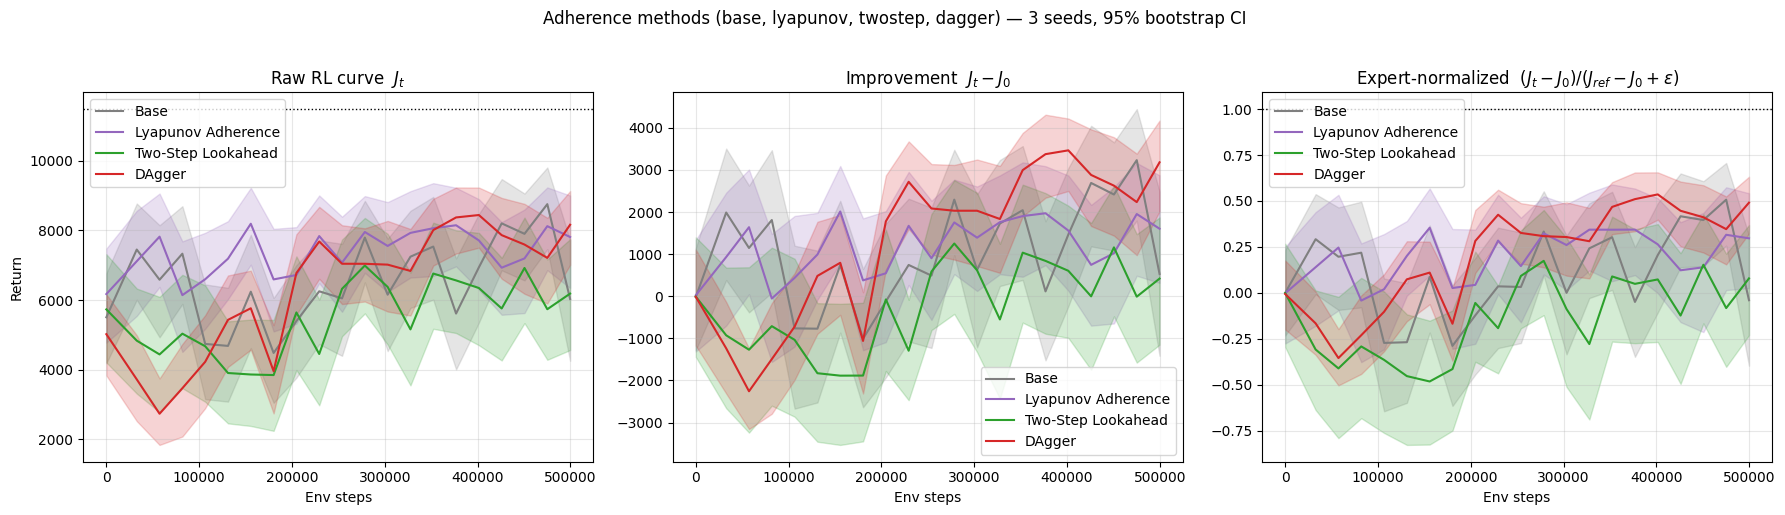

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Raw RL curve  $J_t$',
          'Improvement  $J_t - J_0$',
          r'Expert-normalized  $(J_t-J_0)/(J_{ref}-J_0+\epsilon)$']
which = [0, 1, 2]

for ax, wi, title in zip(axes, which, titles):
    for m in PLOT_METHODS:
        per_unit = curves(m)[wi]
        mean, lo, hi = bootstrap_curve(per_unit)
        ax.plot(STEPS, mean, color=COLORS[m], label=LABELS[m])
        ax.fill_between(STEPS, lo, hi, color=COLORS[m], alpha=0.2)
    ax.set_xlabel('Env steps'); ax.set_title(title); ax.legend()
    ax.grid(alpha=0.3)
axes[0].axhline(J_REF, color='k', ls=':', lw=1, label='expert')
axes[0].set_ylabel('Return')
axes[2].axhline(1.0, color='k', ls=':', lw=1)   # 1.0 = matched expert
plt.suptitle(f'Adherence methods ({", ".join(PLOT_METHODS)}) — '
             f'{len(SEEDS)} seeds, {CI}% bootstrap CI', y=1.02)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/curves_1_3.png', dpi=120, bbox_inches='tight'); plt.show()

## 11 · Curve 4 — Matched-competence comparison

To compare methods at *equal starting competence*, we keep only seeds whose $J_0$ falls in a
shared band (default: within `MATCH_TOL` of the global median $J_0$ across all runs), then on
that matched subset report three scalars per method with bootstrap CIs:

- **Gain-AUC** — area under the improvement curve $\int (J_t - J_0)\,dt$ (trapezoidal over the
  step grid, normalized by total steps → units of "average return gained").
- **Final $J_T$** — end-of-training return.
- **Steps-to-exceed-expert** — first checkpoint step where $J_t \ge J_{\text{ref}}$
  (`inf`/NaN if never reached; reported as % of seeds that reach it).

In [20]:
MATCH_TOL = 400.0    # J0 band half-width around the global median IL-J0

all_J0 = np.concatenate([il_J0(m) for m in PLOT_METHODS])
J0_med = np.median(all_J0)
print(f'Global median IL-J0 = {J0_med:.0f}; matched band = [{J0_med-MATCH_TOL:.0f}, {J0_med+MATCH_TOL:.0f}]')

def matched_seed_mask(method):
    return np.abs(il_J0(method) - J0_med) <= MATCH_TOL

total_span = STEPS[-1] - STEPS[0]
def gain_auc_per_seed(method):
    J = stack_Jt(method)                              # [S,C,E]
    J0 = il_J0(method)                                # [S] stable IL J0
    impr = J.mean(axis=2) - J0[:, None]                # [S,C] improvement curve
    return np.trapz(impr, STEPS, axis=1) / total_span  # [S]

def peak_per_seed(method):
    return stack_Jt(method).mean(axis=2).max(axis=1)   # [S] best checkpoint mean

def late_per_seed_episodes(method):
    """Pooled last-3-checkpoint episodes per seed (robust final performance)."""
    J = stack_Jt(method)                               # [S,C,E]
    k = min(3, J.shape[1])
    return J[:, -k:, :].reshape(J.shape[0], -1)        # [S, k*E]

def steps_to_expert_per_seed(method):
    J = stack_Jt(method).mean(axis=2)                  # [S,C]
    out = []
    for s in range(J.shape[0]):
        hit = np.where(J[s] >= J_REF)[0]
        out.append(STEPS[hit[0]] if len(hit) else np.inf)
    return np.array(out)

rows = []
for m in PLOT_METHODS:
    mask = matched_seed_mask(m)
    if mask.sum() == 0:
        rows.append((m, 0, None, None, None, None, None)); continue
    gauc = gain_auc_per_seed(m)[mask]
    peak = peak_per_seed(m)[mask]
    late = late_per_seed_episodes(m)[mask].reshape(-1)
    ste  = steps_to_expert_per_seed(m)[mask]
    frac_reach = np.isfinite(ste).mean()
    rows.append((m, int(mask.sum()),
                 bootstrap_scalar(gauc),
                 bootstrap_scalar(peak),
                 bootstrap_scalar(late),
                 frac_reach,
                 np.median(ste[np.isfinite(ste)]) if frac_reach>0 else np.inf))

hdr = f'\n{"method":<20}{"n":<4}{"Gain-AUC [CI]":<24}{"J_peak [CI]":<24}{"J_late(last3) [CI]":<26}{"%reach"}'
print(hdr)
for m, n, g, pk, lt, fr, ms in rows:
    if n == 0: print(f'{LABELS[m]:<20}{n:<4}(no matched seeds)'); continue
    print(f'{LABELS[m]:<20}{n:<4}'
          f'{g[0]:6.0f} [{g[1]:.0f},{g[2]:.0f}]   '
          f'{pk[0]:6.0f} [{pk[1]:.0f},{pk[2]:.0f}]   '
          f'{lt[0]:6.0f} [{lt[1]:.0f},{lt[2]:.0f}]    '
          f'{fr*100:4.0f}%')

Global median IL-J0 = 5482; matched band = [5082, 5882]

method              n   Gain-AUC [CI]           J_peak [CI]             J_late(last3) [CI]        %reach
Base                0   (no matched seeds)
Lyapunov Adherence  1     2279 [2279,2279]     9301 [9301,9301]     7919 [6351,9317]       0%
Two-Step Lookahead  0   (no matched seeds)
DAgger              2     1194 [1176,1211]     9389 [9294,9484]     8069 [7338,8754]       0%


/var/folders/xp/vxm8y9zx2l1_4yhq1sjnlg5c0000gn/T/ipykernel_92706/2277486412.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(impr, STEPS, axis=1) / total_span  # [S]


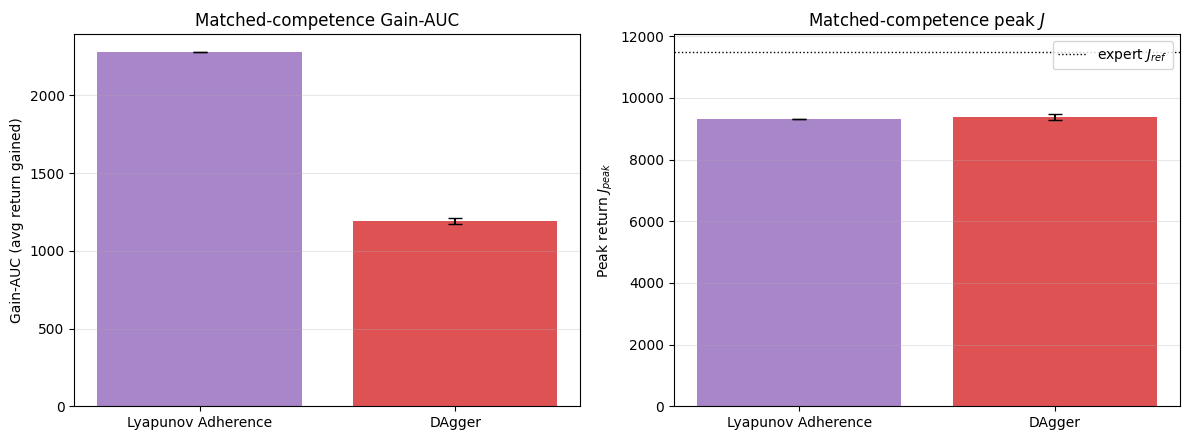

In [21]:
# ── Bar charts: Gain-AUC and J_peak on the matched subset, with bootstrap CIs ──
valid = [r for r in rows if r[1] > 0]
if not valid:
    print('No method has any matched-competence seeds (widen MATCH_TOL in the '
          'previous cell). Skipping bar charts.')
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    xs = np.arange(len(valid)); labels = [LABELS[r[0]] for r in valid]
    cols = [COLORS[r[0]] for r in valid]

    def asym_err(triples):
        mean = np.array([t[0] for t in triples])
        lo   = np.array([t[1] for t in triples])
        hi   = np.array([t[2] for t in triples])
        return np.vstack([np.clip(mean - lo, 0, None), np.clip(hi - mean, 0, None)])

    g_mean = [r[2][0] for r in valid]
    ax[0].bar(xs, g_mean, yerr=asym_err([r[2] for r in valid]),
              color=cols, alpha=0.8, capsize=5)
    ax[0].set_xticks(xs); ax[0].set_xticklabels(labels)
    ax[0].set_ylabel('Gain-AUC (avg return gained)'); ax[0].set_title('Matched-competence Gain-AUC')
    ax[0].grid(alpha=0.3, axis='y')

    p_mean = [r[3][0] for r in valid]
    ax[1].bar(xs, p_mean, yerr=asym_err([r[3] for r in valid]),
              color=cols, alpha=0.8, capsize=5)
    ax[1].axhline(J_REF, color='k', ls=':', lw=1, label='expert $J_{ref}$')
    ax[1].set_xticks(xs); ax[1].set_xticklabels(labels)
    ax[1].set_ylabel('Peak return $J_{peak}$'); ax[1].set_title('Matched-competence peak $J$'); ax[1].legend()
    ax[1].grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/matched_competence.png', dpi=120); plt.show()

## 12 · Export a machine-readable summary

In [22]:
summary = {'seeds': SEEDS, 'run_methods': PLOT_METHODS, 'J_ref': J_REF,
           'steps': STEPS.tolist(), 'ci': CI, 'n_bootstrap': N_BOOTSTRAP, 'methods': {}}
for m in PLOT_METHODS:
    raw, impr, norm = curves(m)
    rmean, rlo, rhi = bootstrap_curve(raw)
    imean, ilo, ihi = bootstrap_curve(impr)
    nmean, nlo, nhi = bootstrap_curve(norm)
    JT   = stack_Jt(m)[:, -1, :].reshape(-1)
    peak = peak_per_seed(m)
    late = late_per_seed_episodes(m).reshape(-1)
    jm, jlo, jhi = bootstrap_scalar(JT)
    pm, plo, phi = bootstrap_scalar(peak)
    lm, llo, lhi = bootstrap_scalar(late)
    energy_vals = np.stack([r['diag_energy_mean'] for r in R[m]], axis=0)  # [S,C]
    knn_vals = np.stack([r['diag_knn_mean'] for r in R[m]], axis=0)        # [S,C]
    summary['methods'][m] = {
        'raw_mean': rmean.tolist(), 'raw_lo': rlo.tolist(), 'raw_hi': rhi.tolist(),
        'impr_mean': imean.tolist(), 'norm_mean': nmean.tolist(),
        'J0_il_mean': float(il_J0(m).mean()),
        'JT_final_mean': float(jm), 'JT_final_ci': [float(jlo), float(jhi)],
        'J_peak_mean': float(pm), 'J_peak_ci': [float(plo), float(phi)],
        'J_late3_mean': float(lm), 'J_late3_ci': [float(llo), float(lhi)],
        'energy_mean_curve': energy_vals.mean(axis=0).tolist(),
        'knn_mean_curve': knn_vals.mean(axis=0).tolist(),
        'J0_energy_mean': float(np.mean([float(r['J0_energy_mean']) for r in R[m]])),
        'J0_knn_mean': float(np.mean([float(r['J0_knn_mean']) for r in R[m]])),
    }
with open(f'{RESULTS_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Wrote', f'{RESULTS_DIR}/summary.json')
print('\nSummary (J0=IL eval; peak/late are collapse-robust):')
print(f'{"method":<20}{"J0":>7}{"J_peak":>10}{"J_late3":>10}{"J_final":>10}{"energy0":>10}{"knn0":>10}')
for m in PLOT_METHODS:
    s = summary['methods'][m]
    print(f'  {LABELS[m]:<18}{s["J0_il_mean"]:7.0f}{s["J_peak_mean"]:10.0f}'
          f'{s["J_late3_mean"]:10.0f}{s["JT_final_mean"]:10.0f}'
          f'{s["J0_energy_mean"]:10.3f}{s["J0_knn_mean"]:10.3f}')

Wrote adherence_agg_results/summary.json

Summary (J0=IL eval; peak/late are collapse-robust):
method                   J0    J_peak   J_late3   J_final   energy0      knn0
  Base                 5507      9302      7573      6033     0.089     6.118
  Lyapunov Adherence   6176      9239      7709      7787     0.048     2.860
  Two-Step Lookahead   5714      8147      6242      6196     0.088     4.144
  DAgger               4992      9264      7679      8193     0.168     3.657


## 13 · Reproduce the curves from CSV alone (self-check)

This appendix reloads **only** `eval_returns_long.csv` (no `.npz`, no globals from the sweep)
and rebuilds the three bootstrap curves. If you come back later, this is the cell to copy into
a fresh notebook — it is fully self-contained given the CSV. Running it here also verifies the
export round-trips: these curves should match Section 10.

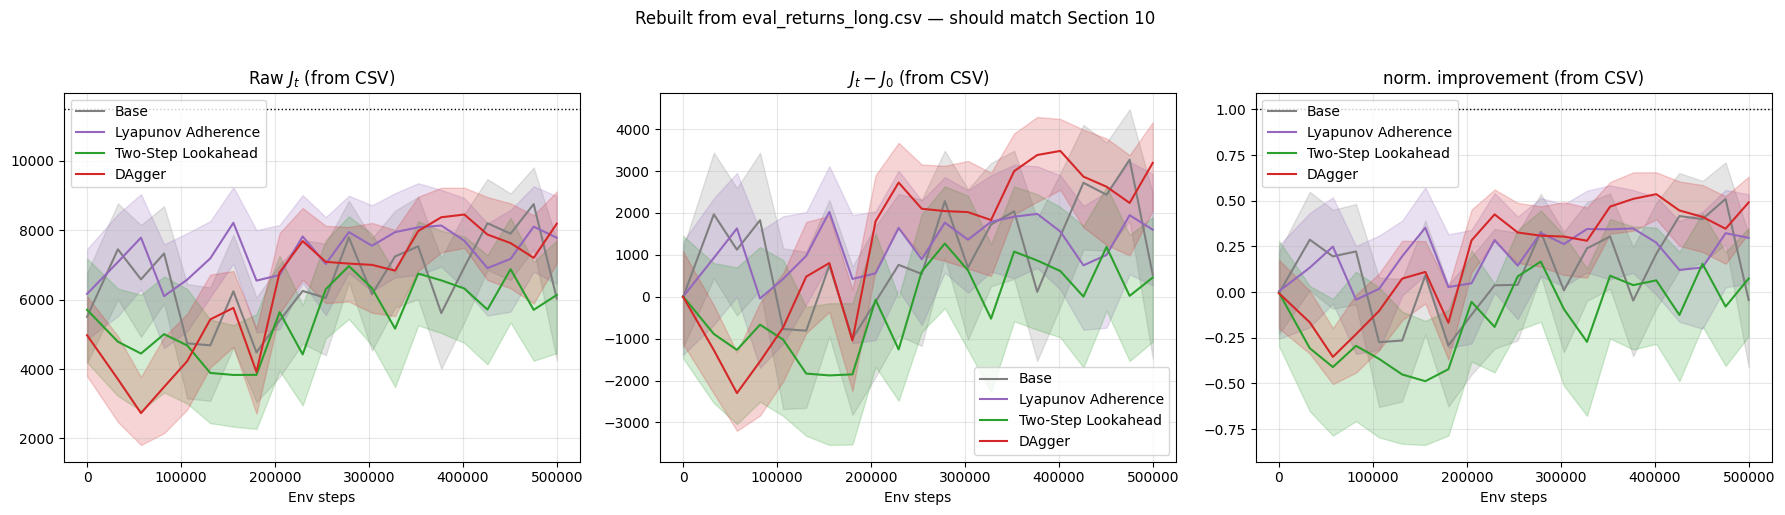

In [23]:
import csv as _csv
from collections import defaultdict

def rebuild_curves_from_csv(csv_path, n_bootstrap=2000, ci=95, eps=1e-6):
    by_ms = defaultdict(lambda: defaultdict(list))
    j0_by_ms = {}
    jref = None; methods = []; steps_set = set()
    with open(csv_path) as f:
        for row in _csv.DictReader(f):
            m, seed, step = row['method'], int(row['seed']), int(row['step'])
            ret = float(row['return']); jref = float(row['J_ref'])
            j0_by_ms[(m, seed)] = float(row['J0'])
            by_ms[m][step].append((seed, ret))
            steps_set.add(step)
            if m not in methods: methods.append(m)
    steps = sorted(steps_set)
    rng = np.random.default_rng(0)
    out = {}
    for m in methods:
        raw_cols, impr_cols, norm_cols = [], [], []
        for step in steps:
            seeds_rets = by_ms[m][step]
            raw = np.array([r for _, r in seeds_rets])
            j0  = np.array([j0_by_ms[(m, s)] for s, _ in seeds_rets])
            raw_cols.append(raw)
            impr_cols.append(raw - j0)
            norm_cols.append((raw - j0) / (jref - j0 + eps))
        def boot(cols):
            M = np.array(cols)
            n = M.shape[1]
            b = np.array([M[:, rng.integers(0, n, n)].mean(1) for _ in range(n_bootstrap)])
            lo, hi = np.percentile(b, [(100-ci)/2, 100-(100-ci)/2], axis=0)
            return b.mean(0), lo, hi
        out[m] = {'steps': np.array(steps),
                  'raw': boot(raw_cols), 'impr': boot(impr_cols), 'norm': boot(norm_cols)}
    return out, jref

_reb, _jref = rebuild_curves_from_csv(os.path.join(RESULTS_DIR, 'eval_returns_long.csv'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, title in zip(axes, ['raw', 'impr', 'norm'],
                          ['Raw $J_t$ (from CSV)', '$J_t-J_0$ (from CSV)',
                           'norm. improvement (from CSV)']):
    for m in _reb:
        st = _reb[m]['steps']; mean, lo, hi = _reb[m][key]
        ax.plot(st, mean, color=COLORS.get(m, None), label=LABELS.get(m, m))
        ax.fill_between(st, lo, hi, color=COLORS.get(m, None), alpha=0.2)
    ax.set_xlabel('Env steps'); ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
axes[0].axhline(_jref, color='k', ls=':', lw=1)
axes[2].axhline(1.0, color='k', ls=':', lw=1)
plt.suptitle('Rebuilt from eval_returns_long.csv — should match Section 10', y=1.02)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/curves_from_csv.png', dpi=120, bbox_inches='tight'); plt.show()

## 14 · Adherence diagnostics + returns box plot

Two views that read the manifold-adherence signal directly rather than inferring it from
returns (replaces the plasticity notebook's dead_frac/eff_rank/weight_l2 panel):

- **Diagnostics curves** — energy-critic score and k-NN manifold distance, each vs. env
  steps, per method (mean over seeds), with the IL-policy's own (step-0) value marked as a
  horizontal reference line. A method that loses manifold adherence during PPO shows
  *rising* energy and *rising* k-NN distance over training; a method that better preserves
  adherence should hold both flatter/lower.
- **Returns box plot** — the full pooled eval-return distribution per method at the **peak**
  checkpoint, side by side with the IL warm start and the expert reference, so the spread
  (not just the mean) is visible.

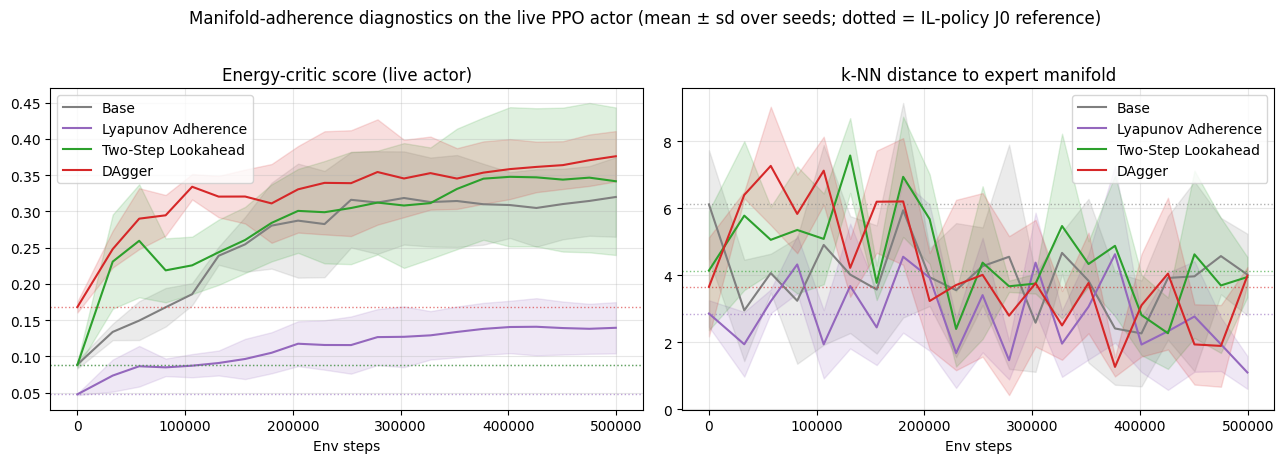

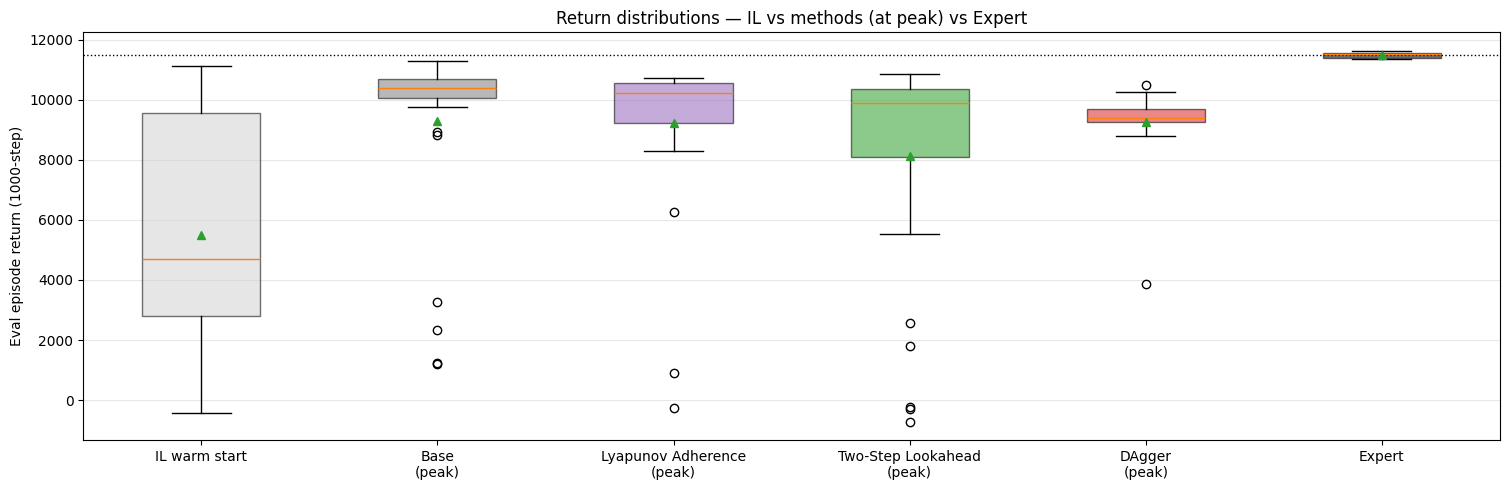

In [24]:
# ── Diagnostics curves (mean over seeds) ─────────────────────────────────────
def stack_diag(method, key):
    runs = [r[key] for r in R[method] if key in r]
    return np.stack(runs, axis=0) if runs else None   # [S, n_ckpt]

fig, axd = plt.subplots(1, 2, figsize=(13, 4.5))
diag_specs = [('diag_energy_mean', 'Energy-critic score (live actor)', axd[0], 'J0_energy_mean'),
              ('diag_knn_mean',    'k-NN distance to expert manifold', axd[1], 'J0_knn_mean')]
have_diag = False
for key, title, ax, j0_key in diag_specs:
    for m in PLOT_METHODS:
        D = stack_diag(m, key)
        if D is None or np.isnan(D).all():
            continue
        have_diag = True
        mean = np.nanmean(D, axis=0); sd = np.nanstd(D, axis=0)
        ax.plot(STEPS, mean, color=COLORS[m], label=LABELS[m])
        ax.fill_between(STEPS, mean - sd, mean + sd, color=COLORS[m], alpha=0.15)
        j0_vals = [float(r[j0_key]) for r in R[m] if j0_key in r]
        if j0_vals:
            ax.axhline(np.mean(j0_vals), color=COLORS[m], ls=':', lw=1, alpha=0.6)
    ax.set_xlabel('Env steps'); ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
if have_diag:
    plt.suptitle('Manifold-adherence diagnostics on the live PPO actor (mean ± sd over seeds; '
                 'dotted = IL-policy J0 reference)', y=1.02)
    plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/adherence_diagnostics.png', dpi=120,
                                    bbox_inches='tight'); plt.show()
else:
    plt.close(fig)
    print('No diagnostics in cache — retrain under the current regime (schema v1_adherence) to populate them.')

# ── Returns box plot at the PEAK checkpoint: IL, each method, expert ──────────
def peak_returns_pooled(method):
    """All eval-episode returns at each seed's own peak checkpoint, pooled."""
    out = []
    for run in R[method]:
        cm = run['Jt_episodes'].mean(axis=1)
        out.append(run['Jt_episodes'][int(cm.argmax())])
    return np.concatenate(out)

def il_returns_pooled(method):
    key = 'J0_il_episodes'
    return np.concatenate([r[key] for r in R[method] if key in r]) \
        if any(key in r for r in R[method]) else np.array([])

box_data, box_labels, box_colors = [], [], []
il_ref_method = 'base' if 'base' in PLOT_METHODS else PLOT_METHODS[0]
il_r = il_returns_pooled(il_ref_method)
if il_r.size:
    box_data.append(il_r); box_labels.append('IL warm start'); box_colors.append('lightgray')
for m in PLOT_METHODS:
    box_data.append(peak_returns_pooled(m)); box_labels.append(f'{LABELS[m]}\n(peak)')
    box_colors.append(COLORS[m])
box_data.append(EXPERT_RETURNS); box_labels.append('Expert'); box_colors.append('black')

fig2, axb = plt.subplots(figsize=(2.2 * len(box_data) + 2, 5))
bp = axb.boxplot(box_data, tick_labels=box_labels, patch_artist=True, showmeans=True)
for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col); patch.set_alpha(0.55)
axb.axhline(J_REF, color='k', ls=':', lw=1)
axb.set_ylabel('Eval episode return (1000-step)')
axb.set_title('Return distributions — IL vs methods (at peak) vs Expert')
axb.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/returns_boxplot.png', dpi=120,
                                bbox_inches='tight'); plt.show()